# *Lepidonotopodium piscesae* — Median Abundance Analysis

<span style="font-family: 'Courier New', monospace;">

*AI-generated draft (Claude, Anthropic) — for review. All parameters and figures are derived from version-controlled scripts and data.*

This notebook implements the advisor-recommended median-per-video abundance method with automated scene selection.

**Core concept:** For each day, one video is selected at a fixed recording time. The notebook automatically identifies the best 1-minute window within the 15-minute Scene 1 block based on lighting quality and camera stability. Every frame within that best minute is analyzed by the YOLO model, and the **median per-frame worm count** becomes the abundance proxy for that day. Repeating this across a month produces a daily time series of median abundance.

**Why median?** The median is resistant to outliers. If a worm moves across the field of view during one frame, or the camera briefly shifts, those frames produce anomalous counts that the median absorbs without distorting the overall estimate.

**Workflow:**
1. **Setup** — configure paths, timing, and scoring parameters
2. **Find daily videos** — one video per day at a fixed recording time
3. **Scene scoring** — extract sparse frames across the 15-minute window and score each candidate minute for brightness and stability
4. **Select best minute** — automatically pick the highest-scoring 1-minute window per video
5. **Extract all frames** — pull every frame from the selected minute at native frame rate
6. **Run YOLO** — count scale worms in every frame
7. **Compute medians** — one abundance value per day
8. **Abundance charts** — visualize the monthly trend
9. **Load manual annotations** — parse VIAME CSVs for comparison
10. **Manual vs AI comparison** — distributional comparison within the Scene 1 window
11. **Summary statistics** — key numbers for AGU

</span>

## 1. Setup

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** Imports all required libraries, defines directory paths, and sets the key parameters that control the entire analysis. All tunable values are collected here so you never need to hunt through the notebook to change a setting.

**Parameters to pay attention to:**
- `DAILY_RECORDING_TIME` — which of the 8 daily recordings to use (e.g. `T061500` = 06:15 UTC). Change this to use a different time of day.
- `WINDOW_START_SEC` / `WINDOW_END_SEC` — the 15-minute Scene 1 block boundaries.
- `SCORE_INTERVAL_SEC` — how often to sample frames during scene scoring (every 10s = 90 candidate frames per video). Smaller = more accurate scoring, slower.
- `BRIGHTNESS_MIN` / `BRIGHTNESS_MAX` — frames outside this range are penalized as too dark or overexposed.
- `CONF_THRESHOLD` — YOLO detection confidence cutoff.

**Expected output:** Confirmation that all paths exist.

</span>

In [3]:
import re
import subprocess
import datetime as dt
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from PIL import Image
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e9c46a',
    'xtick.color':      '#e9c46a',
    'ytick.color':      '#e9c46a',
    'text.color':       '#e9c46a',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

TEAL   = '#2ec4b6'
ORANGE = '#e76f51'
GOLD   = '#e9c46a'
BLUE   = '#457b9d'

# ── Paths ─────────────────────────────────────────────────────────────
MODEL_PATH = Path("/home/jovyan/scaleworm-student-lab/mushroom.pt")
VIDEO_ROOT = Path("/home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301/")
ANNOT_DIR  = Path("/home/jovyan/scaleworm_starter/baseline/annotations_scene1")
WORK_DIR   = Path("./median_abundance_session")
SCORE_DIR  = WORK_DIR / "score_frames"    # sparse frames used for scene scoring
BEST_DIR   = WORK_DIR / "best_frames"     # all frames from the selected best minute
EXPORT_DIR = WORK_DIR / "export"

for d in [WORK_DIR, SCORE_DIR, BEST_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Timing parameters ─────────────────────────────────────────────────
# Which of the 8 daily recordings to use (change to try a different time)
DAILY_RECORDING_TIME = "T061500"   # 06:15 UTC

# 15-minute Scene 1 window boundaries (seconds into video)
WINDOW_START_SEC = 305
WINDOW_END_SEC   = 1205

# Scene 1 boundaries for manual vs AI comparison
SCENE1_START_SEC = 305
SCENE1_END_SEC   = 318

# ── Scene scoring parameters ───────────────────────────────────────────
# One frame every N seconds for scoring (lower = more accurate, slower)
SCORE_INTERVAL_SEC = 10

# Brightness range: frames outside this are penalized (0–255 scale)
BRIGHTNESS_MIN = 40     # below this = too dark
BRIGHTNESS_MAX = 210    # above this = overexposed

# ── Detection parameters ───────────────────────────────────────────────
CONF_THRESHOLD = 0.3
MAX_BOX_SIZE   = 300

print(f"Model       : {MODEL_PATH}  |  exists: {MODEL_PATH.exists()}")
print(f"Video root  : {VIDEO_ROOT}  |  exists: {VIDEO_ROOT.exists()}")
print(f"Annotations : {ANNOT_DIR}  |  exists: {ANNOT_DIR.exists()}")
print(f"Work dir    : {WORK_DIR.resolve()}")
print()
print(f"Daily recording time : {DAILY_RECORDING_TIME}")
print(f"15-min window        : {WINDOW_START_SEC}s – {WINDOW_END_SEC}s")
print(f"Scene 1 (comparison) : {SCENE1_START_SEC}s – {SCENE1_END_SEC}s")
print(f"Score interval       : every {SCORE_INTERVAL_SEC}s")
print(f"Brightness range     : {BRIGHTNESS_MIN}–{BRIGHTNESS_MAX}")

Model       : /home/jovyan/scaleworm-student-lab/mushroom.pt  |  exists: True
Video root  : /home/jovyan/ooi/san_data/RS03ASHS-PN03B-06-CAMHDA301  |  exists: True
Annotations : /home/jovyan/scaleworm_starter/baseline/annotations_scene1  |  exists: True
Work dir    : /home/jovyan/scaleworm-student-lab/notebooks/median_abundance_session

Daily recording time : T061500
15-min window        : 305s – 1205s
Scene 1 (comparison) : 305s – 318s
Score interval       : every 10s
Brightness range     : 40–210


## 2. Find One Video Per Day

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** Scans the video archive for videos matching the fixed daily recording time set in Cell 1 (`DAILY_RECORDING_TIME`). Only one video per day is selected — the recording at that time. This ensures every day contributes exactly one data point to the abundance time series, and that all comparisons are made at the same time of day.

**Expected output:** A list of one video per day across your date range. If a day is missing it means that recording was not archived.

</span>

In [4]:
# ════════════════════════════════════════════════════════════════
# ▼▼▼  SET YOUR DATE RANGE HERE  ▼▼▼
# ════════════════════════════════════════════════════════════════

START_DATE = "2024-10-01"
END_DATE   = "2024-10-31"

# ════════════════════════════════════════════════════════════════

d_start = dt.date.fromisoformat(START_DATE)
d_end   = dt.date.fromisoformat(END_DATE)

daily_videos = {}   # date → video path

for mp4 in sorted(VIDEO_ROOT.rglob("CAMHDA301-*.mp4")):
    m = re.search(r"CAMHDA301-(\d{4})(\d{2})(\d{2})(T\d{6})", mp4.name)
    if not m:
        continue
    file_date = dt.date(int(m.group(1)), int(m.group(2)), int(m.group(3)))
    time_str  = m.group(4)
    if file_date < d_start or file_date > d_end:
        continue
    if time_str != DAILY_RECORDING_TIME:
        continue
    daily_videos[file_date] = mp4

print(f"Recording time : {DAILY_RECORDING_TIME}")
print(f"Date range     : {START_DATE} → {END_DATE}")
print(f"Videos found   : {len(daily_videos)} of {(d_end - d_start).days + 1} days")
print()
for date, vpath in sorted(daily_videos.items()):
    print(f"  {date}  →  {vpath.name}")

Recording time : T061500
Date range     : 2024-10-01 → 2024-10-31
Videos found   : 31 of 31 days

  2024-10-01  →  CAMHDA301-20241001T061500.mp4
  2024-10-02  →  CAMHDA301-20241002T061500.mp4
  2024-10-03  →  CAMHDA301-20241003T061500.mp4
  2024-10-04  →  CAMHDA301-20241004T061500.mp4
  2024-10-05  →  CAMHDA301-20241005T061500.mp4
  2024-10-06  →  CAMHDA301-20241006T061500.mp4
  2024-10-07  →  CAMHDA301-20241007T061500.mp4
  2024-10-08  →  CAMHDA301-20241008T061500.mp4
  2024-10-09  →  CAMHDA301-20241009T061500.mp4
  2024-10-10  →  CAMHDA301-20241010T061500.mp4
  2024-10-11  →  CAMHDA301-20241011T061500.mp4
  2024-10-12  →  CAMHDA301-20241012T061500.mp4
  2024-10-13  →  CAMHDA301-20241013T061500.mp4
  2024-10-14  →  CAMHDA301-20241014T061500.mp4
  2024-10-15  →  CAMHDA301-20241015T061500.mp4
  2024-10-16  →  CAMHDA301-20241016T061500.mp4
  2024-10-17  →  CAMHDA301-20241017T061500.mp4
  2024-10-18  →  CAMHDA301-20241018T061500.mp4
  2024-10-19  →  CAMHDA301-20241019T061500.mp4
  2024-10

## 3. Extract Sparse Frames for Scene Scoring

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** For each daily video, extracts one frame every `SCORE_INTERVAL_SEC` seconds across the full 15-minute window. These frames are not used for worm counting — they are only used in Cell 4 to evaluate which 1-minute window has the best lighting and camera stability.

Extracting sparse frames here keeps this step fast. A 15-minute window at one frame per 10 seconds produces 90 frames per video, which ffmpeg handles in seconds.

Frames are named with their exact offset in seconds (e.g. `offset_0305.png`) so the scoring step can always recover the timestamp from the filename.

Frames that already exist on disk are skipped — this cell is safe to rerun.

**Expected output:** A progress list showing each video and how many scoring frames were extracted.

</span>

In [5]:
SCORE_OFFSETS = list(range(WINDOW_START_SEC, WINDOW_END_SEC, SCORE_INTERVAL_SEC))
print(f"Score offsets per video : {len(SCORE_OFFSETS)}  "
      f"({SCORE_OFFSETS[0]}s – {SCORE_OFFSETS[-1]}s, every {SCORE_INTERVAL_SEC}s)\n")


def extract_frame(video_path, offset_sec, out_path):
    """Extract a single frame at offset_sec from video_path via ffmpeg.
    Returns True if successful, False otherwise.
    """
    if out_path.exists():
        return True
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(offset_sec),
        "-i", str(video_path),
        "-frames:v", "1",
        "-q:v", "2",
        str(out_path),
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=60)
    return result.returncode == 0 and out_path.exists()


score_frame_dirs = {}   # date → directory of scoring frames

for i, (date, vpath) in enumerate(sorted(daily_videos.items())):
    vid_name  = vpath.stem
    frame_dir = SCORE_DIR / vid_name
    frame_dir.mkdir(parents=True, exist_ok=True)
    score_frame_dirs[date] = frame_dir

    n = sum(
        extract_frame(vpath, off, frame_dir / f"offset_{off:04d}.png")
        for off in SCORE_OFFSETS
    )
    print(f"  [{i+1}/{len(daily_videos)}] {vid_name}: {n}/{len(SCORE_OFFSETS)} frames")

print(f"\nDone. Scoring frames saved to: {SCORE_DIR}")

Score offsets per video : 90  (305s – 1195s, every 10s)

  [1/31] CAMHDA301-20241001T061500: 60/90 frames
  [2/31] CAMHDA301-20241002T061500: 60/90 frames
  [3/31] CAMHDA301-20241003T061500: 60/90 frames
  [4/31] CAMHDA301-20241004T061500: 59/90 frames
  [5/31] CAMHDA301-20241005T061500: 59/90 frames
  [6/31] CAMHDA301-20241006T061500: 59/90 frames
  [7/31] CAMHDA301-20241007T061500: 59/90 frames
  [8/31] CAMHDA301-20241008T061500: 59/90 frames
  [9/31] CAMHDA301-20241009T061500: 59/90 frames
  [10/31] CAMHDA301-20241010T061500: 60/90 frames
  [11/31] CAMHDA301-20241011T061500: 59/90 frames
  [12/31] CAMHDA301-20241012T061500: 59/90 frames
  [13/31] CAMHDA301-20241013T061500: 59/90 frames
  [14/31] CAMHDA301-20241014T061500: 59/90 frames
  [15/31] CAMHDA301-20241015T061500: 59/90 frames
  [16/31] CAMHDA301-20241016T061500: 59/90 frames
  [17/31] CAMHDA301-20241017T061500: 59/90 frames
  [18/31] CAMHDA301-20241018T061500: 59/90 frames
  [19/31] CAMHDA301-20241019T061500: 59/90 frames
  

## 4. Score Each Candidate Minute — Brightness & Stability

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** For each video, evaluates every possible 1-minute window within the 15-minute block and assigns it a score based on two criteria:

**Brightness score:** The mean pixel brightness of frames in that window, computed in grayscale. Frames that are too dark (below `BRIGHTNESS_MIN`) or overexposed (above `BRIGHTNESS_MAX`) are penalized by setting their brightness score to zero. A well-lit frame scores proportionally to how close its brightness is to the center of the acceptable range.

**Stability score:** The mean absolute pixel difference between consecutive frames in that window. A high difference means the camera is actively moving between frames. The stability score is inverted so that a still camera scores high and a moving camera scores low.

The two scores are averaged into a single combined score. The 1-minute window with the highest combined score is selected as the best minute for that video.

**Expected output:** A table showing the selected best minute and its score for each video, followed by a diagnostic chart showing how scores vary across the 15-minute window.

</span>

In [6]:
OFFSET_REGEX = re.compile(r"offset_(\d+)\.png")


def score_brightness(img_array):
    """Score a frame on brightness. Returns 0 if outside acceptable range,
    otherwise returns how centered the brightness is within the range.
    """
    gray = np.mean(img_array)   # mean pixel value across all channels
    if gray < BRIGHTNESS_MIN or gray > BRIGHTNESS_MAX:
        return 0.0
    # Score peaks at the midpoint of the acceptable range
    mid   = (BRIGHTNESS_MIN + BRIGHTNESS_MAX) / 2
    half  = (BRIGHTNESS_MAX - BRIGHTNESS_MIN) / 2
    return 1.0 - abs(gray - mid) / half


def score_stability(img_a, img_b):
    """Score stability between two consecutive frames.
    Low pixel difference = camera is still = high score.
    Returns a value between 0 and 1.
    """
    diff = np.mean(np.abs(img_a.astype(float) - img_b.astype(float)))
    # Normalize: diff of 0 = score 1.0, diff of 50+ = score ~0
    return max(0.0, 1.0 - diff / 50.0)


best_minutes  = {}     # date → best start offset (seconds)
all_scores    = {}     # date → list of (offset, combined_score)

for date, frame_dir in sorted(score_frame_dirs.items()):
    frames = sorted(frame_dir.glob("offset_*.png"))
    if not frames:
        print(f"  {date}: no scoring frames found — skipping")
        continue

    # Load all scoring frames for this video
    loaded = {}
    for fp in frames:
        m = OFFSET_REGEX.search(fp.name)
        if m:
            loaded[int(m.group(1))] = np.array(Image.open(fp))

    offsets = sorted(loaded.keys())

    # Score each candidate 1-minute window
    # A window starting at offset S covers frames from S to S+60s
    window_scores = []
    for start in offsets:
        end = start + 60
        window_frames = [(o, img) for o, img in loaded.items()
                         if start <= o < end]
        if len(window_frames) < 2:
            continue

        # Brightness: average score across all frames in window
        b_score = np.mean([score_brightness(img) for _, img in window_frames])

        # Stability: average score across consecutive frame pairs
        imgs    = [img for _, img in sorted(window_frames)]
        s_score = np.mean([
            score_stability(imgs[j], imgs[j+1])
            for j in range(len(imgs)-1)
        ])

        combined = (b_score + s_score) / 2.0
        window_scores.append((start, b_score, s_score, combined))

    if not window_scores:
        print(f"  {date}: could not score any windows — skipping")
        continue

    # Pick the highest-scoring window
    best = max(window_scores, key=lambda x: x[3])
    best_minutes[date] = best[0]
    all_scores[date]   = window_scores

    print(f"  {date}: best window starts at {best[0]}s  "
          f"(brightness={best[1]:.2f}, stability={best[2]:.2f}, "
          f"combined={best[3]:.2f})")

print(f"\nBest minute selected for {len(best_minutes)} videos.")

  2024-10-01: best window starts at 345s  (brightness=0.51, stability=0.83, combined=0.67)
  2024-10-02: best window starts at 825s  (brightness=0.68, stability=0.72, combined=0.70)
  2024-10-03: best window starts at 825s  (brightness=0.71, stability=0.89, combined=0.80)
  2024-10-04: best window starts at 615s  (brightness=0.79, stability=0.41, combined=0.60)
  2024-10-05: best window starts at 615s  (brightness=0.84, stability=0.41, combined=0.63)
  2024-10-06: best window starts at 305s  (brightness=0.00, stability=1.00, combined=0.50)
  2024-10-07: best window starts at 615s  (brightness=0.83, stability=0.50, combined=0.67)
  2024-10-08: best window starts at 615s  (brightness=0.87, stability=0.43, combined=0.65)
  2024-10-09: best window starts at 305s  (brightness=0.68, stability=0.67, combined=0.68)
  2024-10-10: best window starts at 755s  (brightness=0.77, stability=0.86, combined=0.82)
  2024-10-11: best window starts at 615s  (brightness=0.85, stability=0.40, combined=0.63)

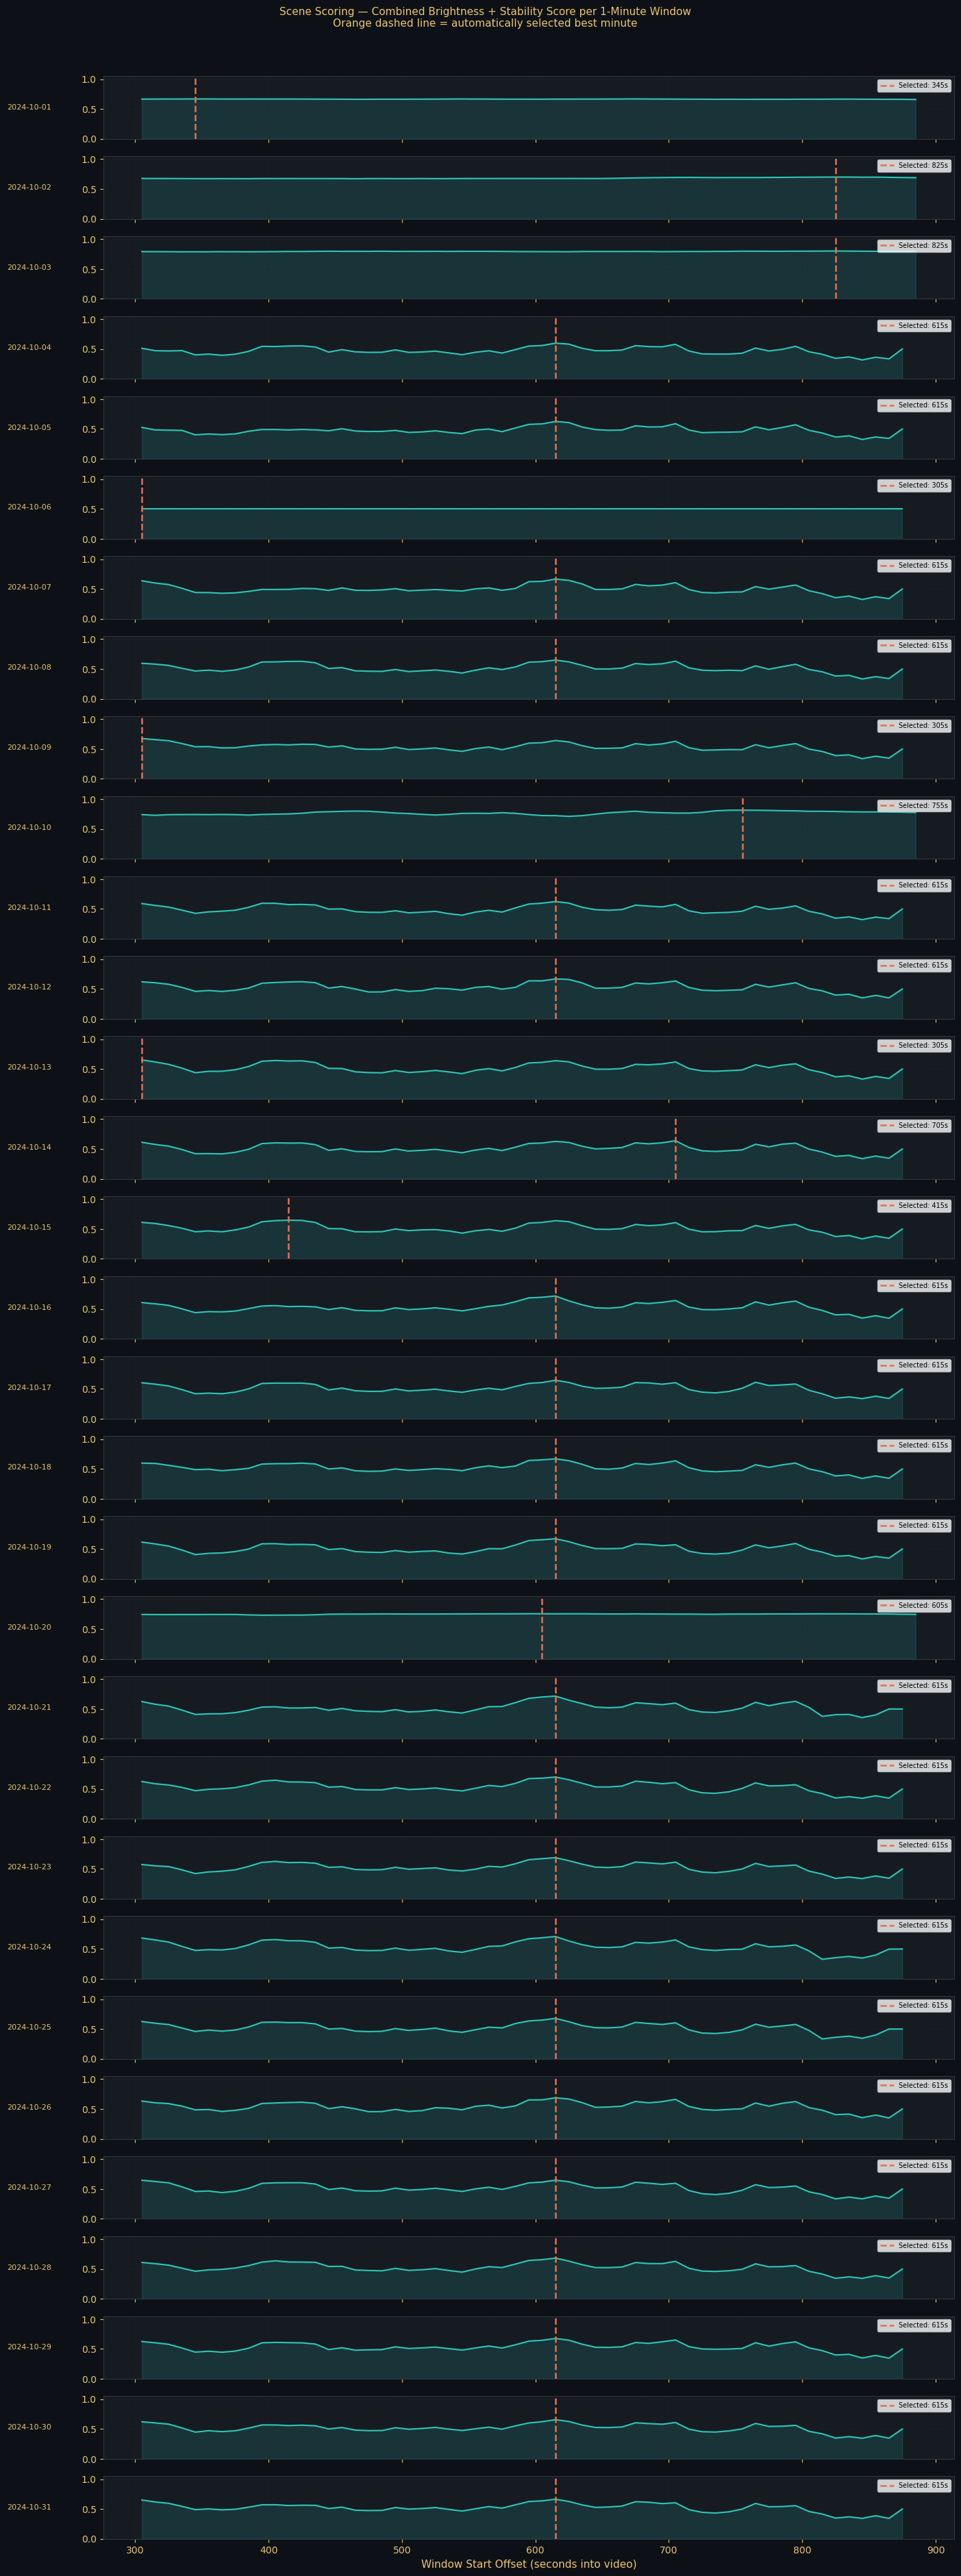

Saved: fig0_scene_scores.png


In [7]:
# ── Diagnostic chart: scene scores across the 15-minute window ────────
# This chart shows how combined scores vary across the window for each
# video. Vertical lines mark the automatically selected best minute.
# Use this to visually validate the selection looks reasonable.

n_videos = len(all_scores)
fig, axes = plt.subplots(
    n_videos, 1,
    figsize=(14, max(3, n_videos * 1.2)),
    sharex=True
)
if n_videos == 1:
    axes = [axes]

for ax, (date, scores) in zip(axes, sorted(all_scores.items())):
    offsets  = [s[0] for s in scores]
    combined = [s[3] for s in scores]
    ax.plot(offsets, combined, color=TEAL, linewidth=1.5)
    ax.fill_between(offsets, combined, alpha=0.15, color=TEAL)
    ax.axvline(best_minutes[date], color=ORANGE, linewidth=1.8,
               linestyle='--', label=f'Selected: {best_minutes[date]}s')
    ax.set_ylabel(str(date), fontsize=8, rotation=0, labelpad=55, va='center')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, facecolor='white', labelcolor='black',
              loc='upper right')

axes[-1].set_xlabel('Window Start Offset (seconds into video)')
fig.suptitle(
    'Scene Scoring — Combined Brightness + Stability Score per 1-Minute Window\n'
    'Orange dashed line = automatically selected best minute',
    fontsize=11, y=1.01
)
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')

fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig0_scene_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig0_scene_scores.png')

## 5. Extract All Frames From the Best Minute

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** For each daily video, extracts every frame within the automatically selected best 1-minute window at the video's native frame rate (~29.97fps). This produces approximately 1,800 frames per video — the full temporal resolution needed to compute a reliable median.

Frames are saved to a per-video subdirectory under `best_frames/`. The ffmpeg `-vf fps=fps` filter is used to extract at the true native frame rate without resampling.

This is the most time-consuming step. A single video's best minute at native frame rate takes approximately 30–60 seconds to extract depending on disk speed.

**Expected output:** A progress list showing each video, the selected window, and the number of frames extracted.

</span>

In [8]:
best_frame_dirs = {}   # date → directory of best-minute frames

for i, (date, vpath) in enumerate(sorted(daily_videos.items())):
    if date not in best_minutes:
        print(f"  [{i+1}] {date}: no best minute selected — skipping")
        continue

    best_start = best_minutes[date]
    vid_name   = vpath.stem
    frame_dir  = BEST_DIR / vid_name
    frame_dir.mkdir(parents=True, exist_ok=True)
    best_frame_dirs[date] = frame_dir

    # Skip if frames already extracted
    existing = sorted(frame_dir.glob("frame_*.png"))
    if len(existing) > 100:
        print(f"  [{i+1}/{len(daily_videos)}] {date}: "
              f"{len(existing)} frames already extracted — skipping")
        continue

    # ── Diagnostic: confirm best_start is within video duration ──────
    probe = subprocess.run(
        ["ffprobe", "-v", "error", "-show_entries", "format=duration",
         "-of", "default=noprint_wrappers=1:nokey=1", str(vpath)],
        capture_output=True, text=True, timeout=30
    )
    try:
        duration = float(probe.stdout.strip())
    except ValueError:
        print(f"  [{i+1}/{len(daily_videos)}] {date}: "
              f"could not read duration — skipping")
        continue

    if best_start + 60 > duration:
        # Clamp window to end of video if needed
        actual_duration = max(0, duration - best_start)
        print(f"  [{i+1}/{len(daily_videos)}] {date}: "
              f"WARNING window {best_start}s+60s exceeds video "
              f"({duration:.0f}s) — clamping to {actual_duration:.0f}s")
        window_duration = actual_duration
    else:
        window_duration = 60

    if window_duration <= 0:
        print(f"  [{i+1}/{len(daily_videos)}] {date}: "
              f"best_start {best_start}s is beyond video end — skipping")
        continue

    # Extract at native frame rate
    # fps=fps was incorrect syntax — use fps=0 to mean native rate,
    # or just omit the -vf filter entirely to get every frame
    cmd = [
        "ffmpeg", "-y",
        "-ss", str(best_start),
        "-i", str(vpath),
        "-t", str(window_duration),
        "-q:v", "2",
        str(frame_dir / "frame_%05d.png")
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)

    n_frames = len(sorted(frame_dir.glob("frame_*.png")))
    if result.returncode != 0 or n_frames == 0:
        print(f"  [{i+1}/{len(daily_videos)}] {date}: "
              f"ERROR — {result.stderr[-200:]}")
    else:
        print(f"  [{i+1}/{len(daily_videos)}] {date}: "
              f"window {best_start}s–{best_start+window_duration:.0f}s "
              f"→ {n_frames} frames")

print(f"\nExtraction complete. {len(best_frame_dirs)} videos ready for YOLO.")

  [1/31] 2024-10-01: window 345s–405s → 1799 frames
  [2/31] 2024-10-02: window 825s–885s → 1798 frames
  [3/31] 2024-10-03: window 825s–885s → 1798 frames
  [4/31] 2024-10-04: window 615s–675s → 1799 frames
  [5/31] 2024-10-05: window 615s–675s → 1799 frames
  [6/31] 2024-10-06: window 305s–365s → 1799 frames
  [7/31] 2024-10-07: window 615s–675s → 1799 frames
  [8/31] 2024-10-08: window 615s–675s → 1799 frames
  [9/31] 2024-10-09: window 305s–365s → 1799 frames
  [10/31] 2024-10-10: window 755s–815s → 1798 frames
  [11/31] 2024-10-11: window 615s–675s → 1799 frames
  [12/31] 2024-10-12: window 615s–675s → 1799 frames
  [13/31] 2024-10-13: window 305s–365s → 1799 frames
  [14/31] 2024-10-14: window 705s–765s → 1799 frames
  [15/31] 2024-10-15: window 415s–475s → 1799 frames
  [16/31] 2024-10-16: window 615s–675s → 1799 frames
  [17/31] 2024-10-17: window 615s–675s → 1799 frames
  [18/31] 2024-10-18: window 615s–675s → 1799 frames
  [19/31] 2024-10-19: window 615s–675s → 1799 frames
  

## 6. Run YOLO on Every Frame in the Best Minute

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** Runs the YOLO Mushroom Model on every extracted frame from the best minute. For each frame, the number of scale worm detections above the confidence threshold is recorded. Detections with bounding boxes larger than `MAX_BOX_SIZE` pixels are filtered out as they are unlikely to be real worms.

The result is a DataFrame with one row per frame, storing the date, frame index, and worm count. This is the raw data from which the median is computed in the next step.

No object tracking is applied here — each frame is treated as independent. The median in the next step naturally handles the fact that the same worm may appear across many frames.

**Expected output:** A progress list per video showing frame count, min, max, and median detections, followed by a preview of the results table.

</span>

In [9]:
!pip install ultralytics -q

In [11]:
from ultralytics import YOLO
import torch

model = YOLO(str(MODEL_PATH))
print(f"Loaded: {MODEL_PATH.name}\n")

# ── Tune this if you still get OOM errors ─────────────────────────────
# Lower = less GPU memory per batch, slower overall
# Raise = faster, but risks OOM if frames are large
BATCH_SIZE = 8

frame_records = []

for date, frame_dir in sorted(best_frame_dirs.items()):
    frame_paths = sorted(frame_dir.glob("frame_*.png"))
    if not frame_paths:
        print(f"  {date}: no frames found — skipping")
        continue

    frame_counts = []

    # Process in batches to avoid OOM
    for batch_start in range(0, len(frame_paths), BATCH_SIZE):
        batch = frame_paths[batch_start : batch_start + BATCH_SIZE]

        results = model.predict(
            source=[str(f) for f in batch],
            conf=CONF_THRESHOLD,
            verbose=False,
            stream=True,
        )

        for frame_path, result in zip(batch, results):
            count = 0
            if result.boxes is not None and len(result.boxes) > 0:
                for box in result.boxes.xyxy.cpu().numpy():
                    x1, y1, x2, y2 = box
                    if (x2-x1) <= MAX_BOX_SIZE and (y2-y1) <= MAX_BOX_SIZE:
                        count += 1

            frame_records.append({
                'date':       pd.to_datetime(date),
                'frame_idx':  batch_start + batch.index(frame_path),
                'frame_name': frame_path.name,
                'best_start': best_minutes[date],
                'det_count':  count,
            })
            frame_counts.append(count)

        # Clear GPU cache between batches to free memory
        torch.cuda.empty_cache()

    print(f"  {date}: {len(frame_counts)} frames | "
          f"min={min(frame_counts)}  "
          f"max={max(frame_counts)}  "
          f"median={np.median(frame_counts):.1f}")

frames_df = pd.DataFrame(frame_records)
print(f"\nTotal frames processed: {len(frames_df):,}")
frames_df.head()

Loaded: mushroom.pt

  2024-10-01: 1799 frames | min=0  max=1  median=0.0
  2024-10-02: 1798 frames | min=0  max=5  median=1.0
  2024-10-03: 1798 frames | min=0  max=1  median=0.0
  2024-10-04: 1799 frames | min=0  max=1  median=0.0
  2024-10-05: 1799 frames | min=0  max=3  median=0.0
  2024-10-06: 1799 frames | min=0  max=0  median=0.0
  2024-10-07: 1799 frames | min=0  max=2  median=0.0
  2024-10-08: 1799 frames | min=0  max=2  median=0.0
  2024-10-09: 1799 frames | min=0  max=3  median=0.0
  2024-10-10: 1798 frames | min=0  max=1  median=0.0
  2024-10-11: 1799 frames | min=0  max=1  median=0.0
  2024-10-12: 1799 frames | min=0  max=3  median=1.0
  2024-10-13: 1799 frames | min=0  max=2  median=0.0
  2024-10-14: 1799 frames | min=0  max=2  median=0.0
  2024-10-15: 1799 frames | min=0  max=1  median=0.0
  2024-10-16: 1799 frames | min=0  max=4  median=1.0
  2024-10-17: 1799 frames | min=0  max=1  median=0.0
  2024-10-18: 1799 frames | min=0  max=2  median=0.0
  2024-10-19: 1799 frames

,date,frame_idx,frame_name,best_start,det_count
0,2024-10-01,0,frame_00001.png,345,0
1,2024-10-01,1,frame_00002.png,345,0
2,2024-10-01,2,frame_00003.png,345,0
3,2024-10-01,3,frame_00004.png,345,0
4,2024-10-01,4,frame_00005.png,345,0


## 7. Compute Daily Median Abundance

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** Computes the median, mean, standard deviation, IQR, min, and max of per-frame worm counts for each day. The **median** is the primary abundance proxy — it represents the most typical number of scale worms visible in any given frame of that day's best minute.

The IQR (interquartile range = 75th percentile minus 25th percentile) is also computed. A wide IQR on a given day means worm counts were highly variable across frames — this could indicate worm movement, partial occlusion, or camera instability that the scorer did not fully filter out.

**Expected output:** A table with one row per day showing all computed statistics.

</span>

In [12]:
daily = (
    frames_df.groupby('date')['det_count']
    .agg(
        median      = 'median',
        mean        = 'mean',
        std         = 'std',
        min         = 'min',
        max         = 'max',
        q25         = lambda x: x.quantile(0.25),
        q75         = lambda x: x.quantile(0.75),
        frame_count = 'count',
    )
    .reset_index()
    .sort_values('date')
)
daily['iqr']  = daily['q75'] - daily['q25']
daily['date'] = pd.to_datetime(daily['date'])

# Attach best minute info
daily['best_start_sec'] = daily['date'].map(
    {pd.to_datetime(k): v for k, v in best_minutes.items()}
)

print(f"Days with data: {len(daily)}")
print()
print(daily[['date','best_start_sec','median','mean','std',
             'min','max','iqr','frame_count']].to_string(index=False))

Days with data: 31

      date  best_start_sec  median     mean      std  min  max  iqr  frame_count
2024-10-01             345     0.0 0.007226 0.084723    0    1  0.0         1799
2024-10-02             825     1.0 1.128476 1.054793    0    5  2.0         1798
2024-10-03             825     0.0 0.001112 0.033343    0    1  0.0         1798
2024-10-04             615     0.0 0.001112 0.033333    0    1  0.0         1799
2024-10-05             615     0.0 0.299611 0.472556    0    3  1.0         1799
2024-10-06             305     0.0 0.000000 0.000000    0    0  0.0         1799
2024-10-07             615     0.0 0.018344 0.138309    0    2  0.0         1799
2024-10-08             615     0.0 0.016120 0.130313    0    2  0.0         1799
2024-10-09             305     0.0 0.245136 0.492940    0    3  0.0         1799
2024-10-10             755     0.0 0.000556 0.023583    0    1  0.0         1798
2024-10-11             615     0.0 0.033352 0.179604    0    1  0.0         1799
2024-10-

## 8. Abundance Over Time Charts

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** Produces three charts visualizing the daily median abundance time series:

- **Chart 1 — Daily median with IQR band:** The teal line is the median worm count per day. The shaded band shows the IQR — wider bands indicate higher within-day variability. The dashed gold line shows the mean for comparison.
- **Chart 2 — Daily median with 7-day rolling mean:** Smooths short-term noise to reveal the broader monthly trend. Useful for identifying multi-day patterns.
- **Chart 3 — Per-frame count distribution heatmap:** Shows the full distribution of worm counts across all frames for each day. Darker cells = more frames with that count. This reveals whether the median is a good central estimate or whether the distribution is bimodal or skewed.

All charts are saved to the export directory.

</span>

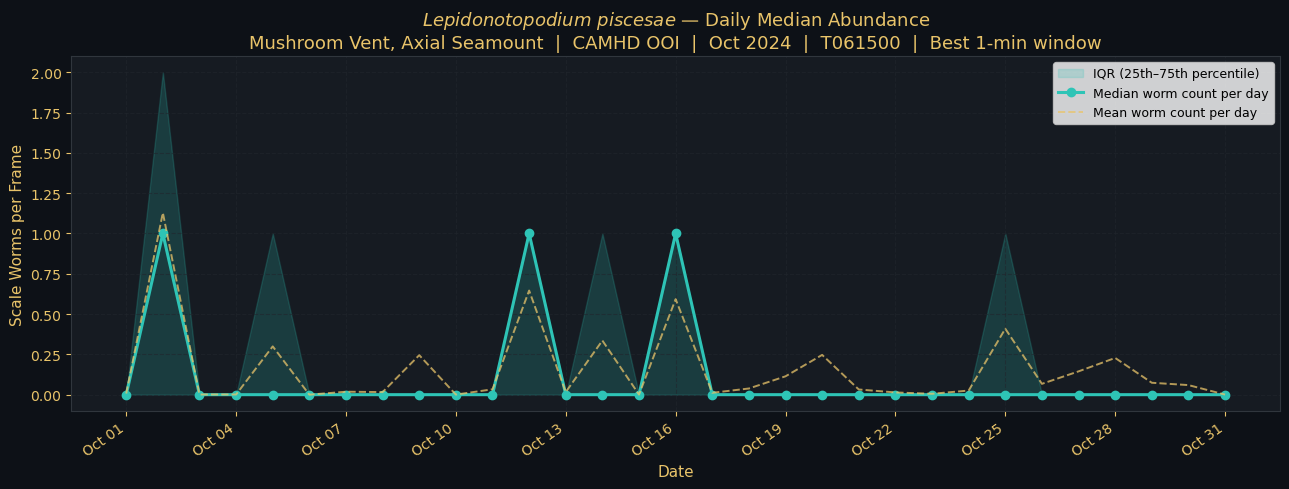

Saved: fig1_daily_median.png


In [13]:
# ── Chart 1: Daily median with IQR band ──────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(daily['date'], daily['q25'], daily['q75'],
                alpha=0.20, color=TEAL, label='IQR (25th–75th percentile)')
ax.plot(daily['date'], daily['median'],
        color=TEAL, linewidth=2.2, marker='o', markersize=6,
        label='Median worm count per day')
ax.plot(daily['date'], daily['mean'],
        color=GOLD, linewidth=1.4, linestyle='--', alpha=0.75,
        label='Mean worm count per day')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Scale Worms per Frame')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Daily Median Abundance'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
    f'  |  {DAILY_RECORDING_TIME}  |  Best 1-min window'
)
ax.legend(facecolor='white', labelcolor='black', fontsize=9)
ax.grid(True)
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig1_daily_median.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_daily_median.png')

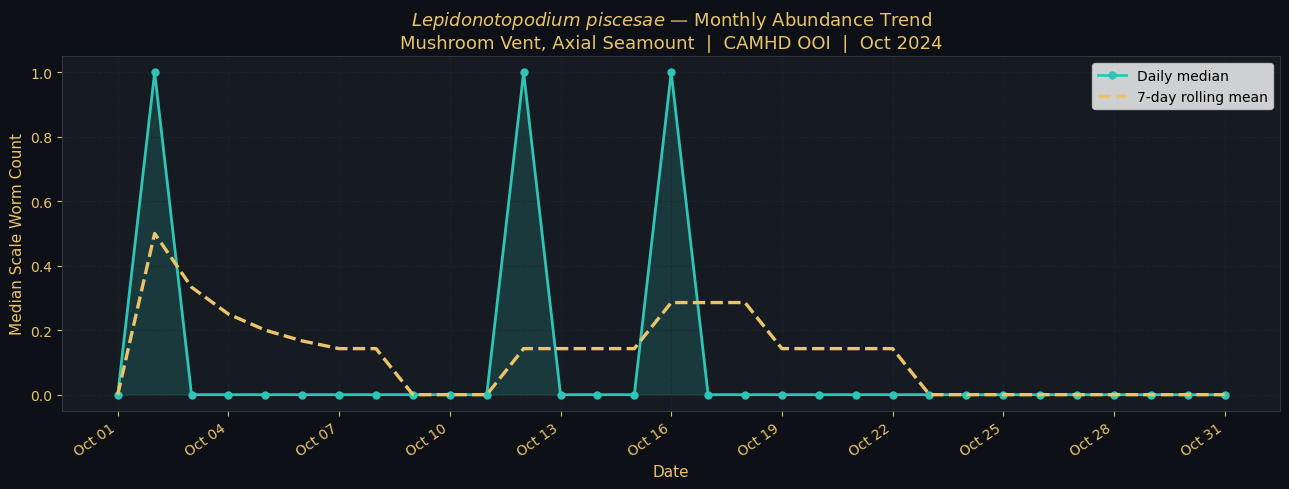

Saved: fig2_rolling_mean.png


In [14]:
# ── Chart 2: Daily median with 7-day rolling mean ────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(daily['date'], daily['median'], alpha=0.18, color=TEAL)
ax.plot(daily['date'], daily['median'],
        color=TEAL, linewidth=2, marker='o', markersize=5,
        label='Daily median')

if len(daily) >= 7:
    rolling = daily.set_index('date')['median'].rolling('7D').mean()
    ax.plot(rolling.index, rolling.values,
            color=GOLD, linewidth=2.4, linestyle='--',
            label='7-day rolling mean')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=35, ha='right')
ax.set_xlabel('Date')
ax.set_ylabel('Median Scale Worm Count')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Monthly Abundance Trend'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI  |  Oct 2024'
)
ax.legend(facecolor='white', labelcolor='black')
ax.grid(True)
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig2_rolling_mean.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_rolling_mean.png')

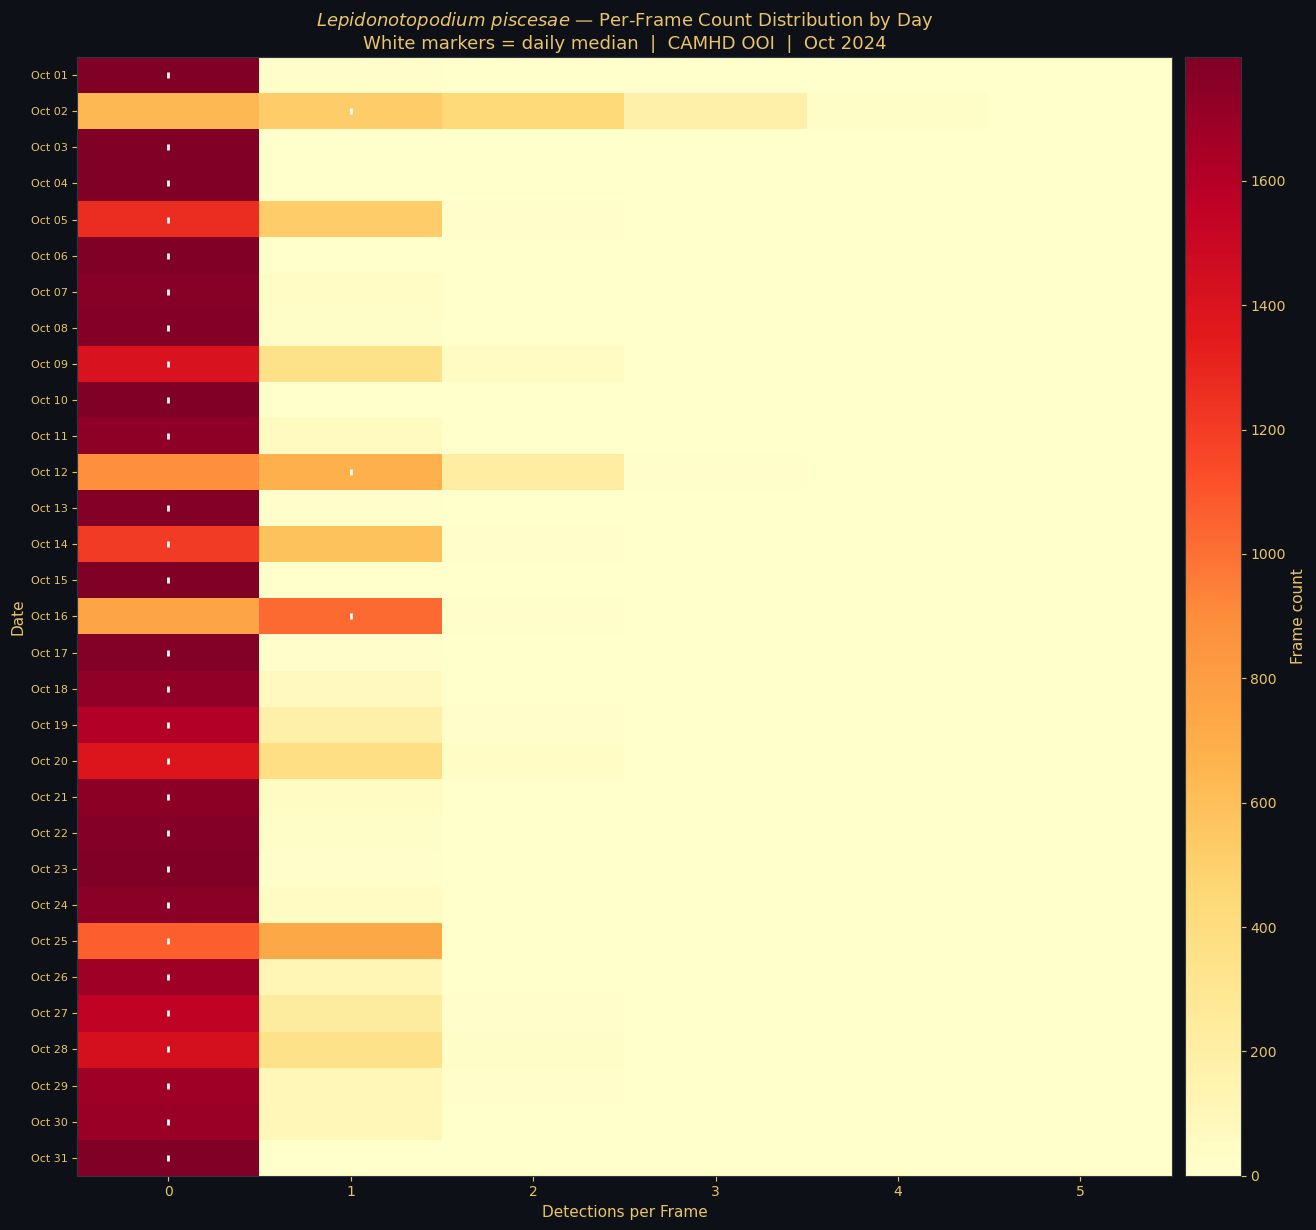

Saved: fig3_distribution_heatmap.png


In [15]:
# ── Chart 3: Per-frame count distribution heatmap ────────────────────
# Rows = days, columns = detection count (0, 1, 2, ...)
# Cell value = number of frames with that count on that day
# This shows whether the median is a good central estimate

max_count = int(frames_df['det_count'].max())
heatmap_rows = []

for _, row in daily.iterrows():
    day_counts = frames_df[frames_df['date'] == row['date']]['det_count'].values
    hist, _ = np.histogram(day_counts, bins=range(0, max_count + 2))
    heatmap_rows.append(hist)

heatmap_data = np.array(heatmap_rows)
date_labels  = [d.strftime('%b %d') for d in daily['date']]

fig, ax = plt.subplots(figsize=(14, max(5, len(daily) * 0.4)))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd',
               interpolation='nearest')
cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label('Frame count', color=GOLD)
cbar.ax.yaxis.set_tick_params(color=GOLD)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=GOLD)

ax.set_xticks(range(max_count + 1))
ax.set_xticklabels(range(max_count + 1))
ax.set_yticks(range(len(date_labels)))
ax.set_yticklabels(date_labels, fontsize=8)

# Overlay median markers
for i, med in enumerate(daily['median']):
    ax.scatter(med, i, color='white', s=25, zorder=3, marker='|', linewidths=2)

ax.set_xlabel('Detections per Frame')
ax.set_ylabel('Date')
ax.set_title(
    r'$Lepidonotopodium\ piscesae$ — Per-Frame Count Distribution by Day'
    '\nWhite markers = daily median  |  CAMHD OOI  |  Oct 2024'
)
fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig3_distribution_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_distribution_heatmap.png')

## 9. Load Manual VIAME Annotations

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** Parses the expert human annotation CSVs from the VIAME annotation tool. These annotations were made on Scene 1 footage from March, June, and August 2023 — the data used to train the Mushroom Model. Each row in a VIAME CSV is one detection in one frame.

The CSVs have two comment/metadata lines at the top that are skipped. The remaining rows are filtered to `scale_worm` detections only. Per-frame worm counts are then computed by counting how many detections appear in each frame number.

Because the VIAME annotations cover only ~13 seconds of Scene 1 footage at 10fps, and the YOLO detections cover a full 60-second best minute, the comparison in the next step uses only YOLO frames that fall within the Scene 1 window (`SCENE1_START_SEC` to `SCENE1_END_SEC`) to ensure a fair distributional comparison.

**Expected output:** Detection count per CSV, total annotations, and date range covered.

</span>

In [16]:
COL_NAMES   = [
    'track_id', 'timestamp', 'frame_num',
    'tl_x', 'tl_y', 'br_x', 'br_y',
    'confidence', 'target_length', 'species', 'species_conf'
]
VIAME_REGEX = re.compile(r"CAMHDA301-(\d{8})T(\d{6})")

annot_records = []
csvs = sorted(ANNOT_DIR.glob("*.csv"))
print(f"Loading {len(csvs)} annotation CSVs...\n")

for csv_path in csvs:
    m = VIAME_REGEX.search(csv_path.stem)
    if not m:
        print(f"  WARNING: could not parse date from {csv_path.name} — skipping")
        continue
    vid_date = pd.to_datetime(m.group(1), format='%Y%m%d').date()

    df = pd.read_csv(csv_path, header=None, skiprows=2,
                     names=COL_NAMES, on_bad_lines='skip')
    df = df[df['species'].astype(str).str.strip() == 'scale_worm'].copy()
    df['date']     = vid_date
    df['csv_file'] = csv_path.name
    annot_records.append(df)
    print(f"  {csv_path.name}: {len(df)} detections")

annot_df              = pd.concat(annot_records, ignore_index=True)
annot_df['frame_num'] = pd.to_numeric(annot_df['frame_num'], errors='coerce')
annot_df['date']      = pd.to_datetime(annot_df['date'])

# Per-frame count from manual annotations
manual_per_frame = (
    annot_df.groupby(['csv_file', 'date', 'frame_num'])['track_id']
    .count()
    .reset_index()
    .rename(columns={'track_id': 'det_count'})
)

print(f"\nTotal manual detections  : {len(annot_df):,}")
print(f"Date range               : "
      f"{annot_df['date'].min().date()} to {annot_df['date'].max().date()}")
print(f"Unique videos annotated  : {annot_df['csv_file'].nunique()}")
print(f"Per-frame count range    : "
      f"{manual_per_frame['det_count'].min()} – "
      f"{manual_per_frame['det_count'].max()}")

Loading 39 annotation CSVs...

  CAMHDA301-20230305T001500_scene1.csv: 2730 detections
  CAMHDA301-20230306T001500_scene1.csv: 895 detections
  CAMHDA301-20230312T001500_scene1.csv: 927 detections
  CAMHDA301-20230313T001500_scene1.csv: 1133 detections
  CAMHDA301-20230316T001500_scene1.csv: 2079 detections
  CAMHDA301-20230317T001500_scene1.csv: 1400 detections
  CAMHDA301-20230318T001500_scene1.csv: 2060 detections
  CAMHDA301-20230319T001500_scene1.csv: 1700 detections
  CAMHDA301-20230322T001500_scene1.csv: 1352 detections
  CAMHDA301-20230323T001500_scene1.csv: 1600 detections
  CAMHDA301-20230325T001500_scene1.csv: 742 detections
  CAMHDA301-20230326T001500_scene1.csv: 1060 detections
  CAMHDA301-20230328T001500_scene1.csv: 714 detections
  CAMHDA301-20230329T001500_scene1.csv: 535 detections
  CAMHDA301-20230330T001500_scene1.csv: 2100 detections
  CAMHDA301-20230331T001500_scene1.csv: 848 detections
  CAMHDA301-20230406T001500_scene1.csv: 1400 detections
  CAMHDA301-20230407T00

## 10. Manual vs AI Comparison

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** Compares the distribution of per-frame worm counts between the YOLO model and human expert annotations. To make this comparison fair, only YOLO frames from the Scene 1 window (`SCENE1_START_SEC` to `SCENE1_END_SEC`) are used, since that is the same portion of the video covered by the VIAME CSVs.

The comparison is **distributional** rather than frame-by-frame because the two datasets cover different years (2023 manual, 2024 YOLO). The question being asked is: does the model produce ecologically plausible counts relative to what a human expert observed at the same vent?

Four panels are produced:
- **Overlaid histograms** — frequency of per-frame counts for each method
- **Box plots** — side-by-side summary statistics
- **Per-video median distributions** — how spread out the video-level medians are for each method
- **Summary statistics table** — numeric comparison including a Mann-Whitney U test for statistical significance

**Expected output:** A four-panel chart saved to the export directory, and printed statistics.

</span>

/tmp/ipykernel_89/865739394.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


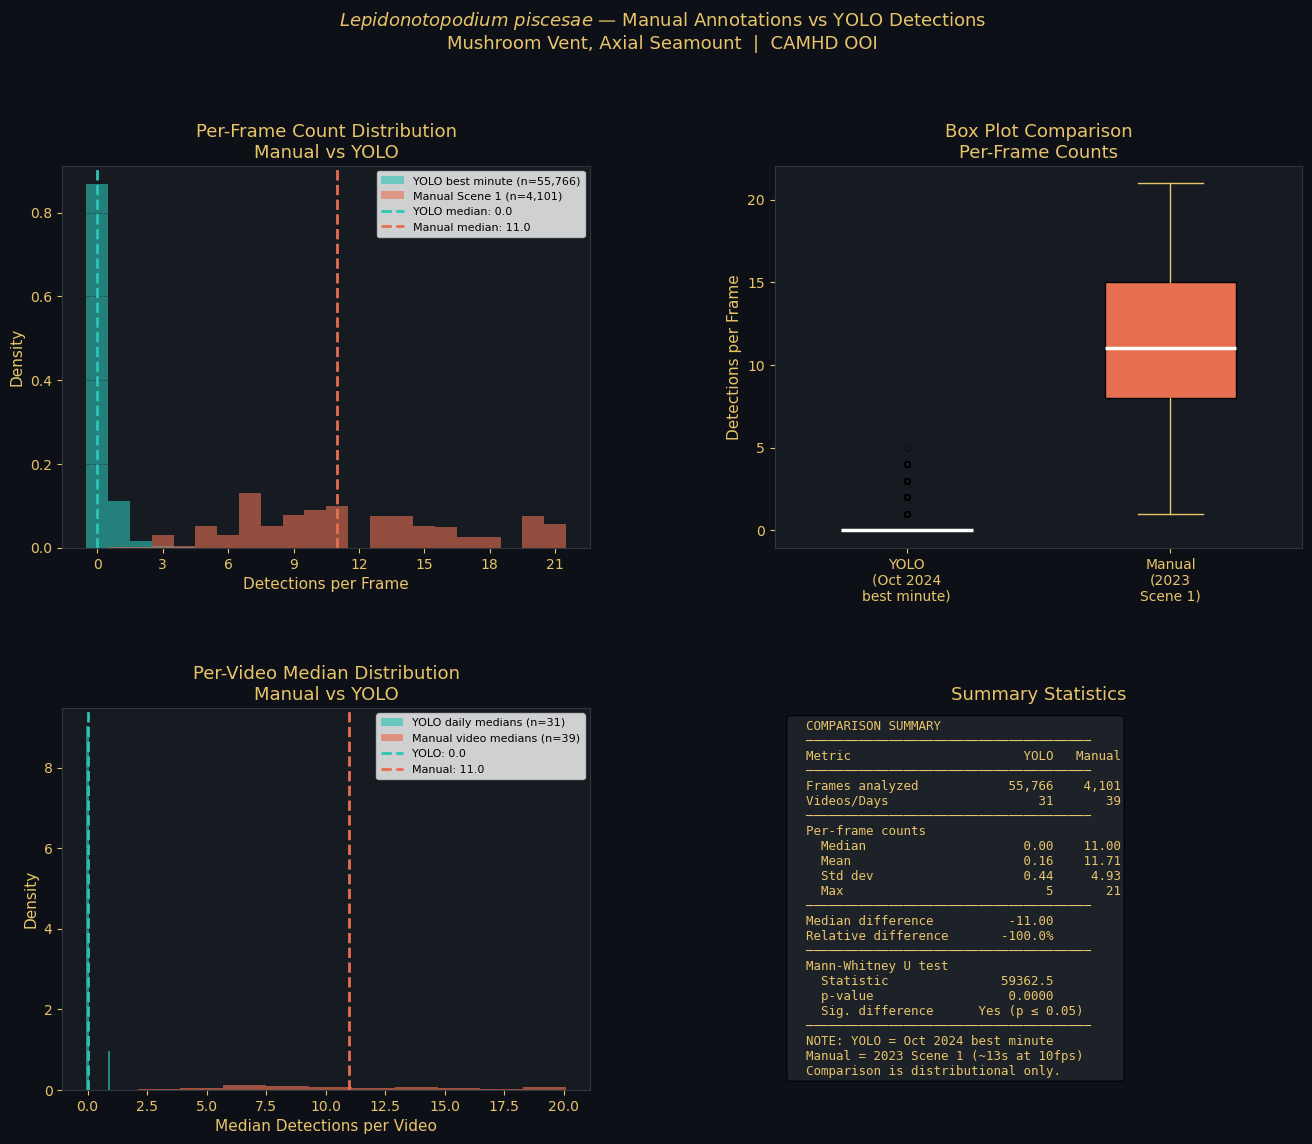

Saved: fig4_manual_vs_ai.png


In [17]:
# YOLO frames that fall within the Scene 1 window
# Scene 1 frames are those where best_start_sec == SCENE1_START_SEC
# (i.e. the best minute happened to start at the Scene 1 offset)
# OR we use all frames and note the comparison caveat
# Since the best minute is auto-selected, we compare all best-minute
# frames against manual Scene 1 frames and note the distinction

yolo_counts   = frames_df['det_count'].values
manual_counts = manual_per_frame['det_count'].values

# Per-video medians
yolo_medians   = daily['median'].values
manual_medians = (
    manual_per_frame.groupby('csv_file')['det_count']
    .median().values
)

# Mann-Whitney U test
mw_stat, mw_p = stats.mannwhitneyu(
    yolo_counts, manual_counts, alternative='two-sided'
)
sig_str = 'Yes (p ≤ 0.05)' if mw_p <= 0.05 else 'No (p > 0.05)'
diff    = np.median(yolo_counts) - np.median(manual_counts)
pct_diff= (diff / np.median(manual_counts) * 100
           if np.median(manual_counts) != 0 else float('nan'))

# ── Four-panel chart ──────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# Panel 1 — Overlaid histograms
ax1 = fig.add_subplot(gs[0, 0])
max_count = max(int(yolo_counts.max()), int(manual_counts.max()))
bins = range(0, max_count + 2)
ax1.hist(yolo_counts,   bins=bins, color=TEAL,   alpha=0.6, density=True,
         align='left', label=f'YOLO best minute (n={len(yolo_counts):,})')
ax1.hist(manual_counts, bins=bins, color=ORANGE, alpha=0.6, density=True,
         align='left', label=f'Manual Scene 1 (n={len(manual_counts):,})')
ax1.axvline(np.median(yolo_counts),
            color=TEAL,   linewidth=2, linestyle='--',
            label=f'YOLO median: {np.median(yolo_counts):.1f}')
ax1.axvline(np.median(manual_counts),
            color=ORANGE, linewidth=2, linestyle='--',
            label=f'Manual median: {np.median(manual_counts):.1f}')
ax1.set_xlabel('Detections per Frame')
ax1.set_ylabel('Density')
ax1.set_title('Per-Frame Count Distribution\nManual vs YOLO')
ax1.legend(facecolor='white', labelcolor='black', fontsize=8)
ax1.grid(True, axis='y', alpha=0.4)
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 2 — Box plots
ax2 = fig.add_subplot(gs[0, 1])
bp  = ax2.boxplot(
    [yolo_counts, manual_counts],
    patch_artist=True, vert=True, widths=0.5,
    medianprops=dict(linewidth=2.5, color='white'),
    whiskerprops=dict(color=GOLD),
    capprops=dict(color=GOLD),
    flierprops=dict(marker='o', markersize=4, alpha=0.4)
)
bp['boxes'][0].set_facecolor(TEAL)
bp['boxes'][1].set_facecolor(ORANGE)
bp['fliers'][0].set_color(TEAL)
bp['fliers'][1].set_color(ORANGE)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['YOLO\n(Oct 2024\nbest minute)', 'Manual\n(2023\nScene 1)'])
ax2.set_ylabel('Detections per Frame')
ax2.set_title('Box Plot Comparison\nPer-Frame Counts')
ax2.grid(True, axis='y', alpha=0.4)

# Panel 3 — Per-video median distributions
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(yolo_medians,   bins=10, color=TEAL,   alpha=0.65, density=True,
         label=f'YOLO daily medians (n={len(yolo_medians)})',   align='left')
ax3.hist(manual_medians, bins=10, color=ORANGE, alpha=0.65, density=True,
         label=f'Manual video medians (n={len(manual_medians)})', align='left')
ax3.axvline(np.median(yolo_medians),
            color=TEAL,   linewidth=2, linestyle='--',
            label=f'YOLO: {np.median(yolo_medians):.1f}')
ax3.axvline(np.median(manual_medians),
            color=ORANGE, linewidth=2, linestyle='--',
            label=f'Manual: {np.median(manual_medians):.1f}')
ax3.set_xlabel('Median Detections per Video')
ax3.set_ylabel('Density')
ax3.set_title('Per-Video Median Distribution\nManual vs YOLO')
ax3.legend(facecolor='white', labelcolor='black', fontsize=8)
ax3.grid(True, axis='y', alpha=0.4)

# Panel 4 — Summary statistics table
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
table_text = (
    f"  COMPARISON SUMMARY\n"
    f"  {'─'*38}\n"
    f"  {'Metric':<24} {'YOLO':>8} {'Manual':>8}\n"
    f"  {'─'*38}\n"
    f"  {'Frames analyzed':<24} {len(yolo_counts):>8,} {len(manual_counts):>8,}\n"
    f"  {'Videos/Days':<24} {len(yolo_medians):>8} {len(manual_medians):>8}\n"
    f"  {'─'*38}\n"
    f"  Per-frame counts\n"
    f"  {'  Median':<24} {np.median(yolo_counts):>8.2f} {np.median(manual_counts):>8.2f}\n"
    f"  {'  Mean':<24} {np.mean(yolo_counts):>8.2f} {np.mean(manual_counts):>8.2f}\n"
    f"  {'  Std dev':<24} {np.std(yolo_counts):>8.2f} {np.std(manual_counts):>8.2f}\n"
    f"  {'  Max':<24} {int(yolo_counts.max()):>8} {int(manual_counts.max()):>8}\n"
    f"  {'─'*38}\n"
    f"  {'Median difference':<24} {diff:>+8.2f}\n"
    f"  {'Relative difference':<24} {pct_diff:>+7.1f}%\n"
    f"  {'─'*38}\n"
    f"  Mann-Whitney U test\n"
    f"  {'  Statistic':<24} {mw_stat:>8.1f}\n"
    f"  {'  p-value':<24} {mw_p:>8.4f}\n"
    f"  {'  Sig. difference':<22} {sig_str}\n"
    f"  {'─'*38}\n"
    f"  NOTE: YOLO = Oct 2024 best minute\n"
    f"  Manual = 2023 Scene 1 (~13s at 10fps)\n"
    f"  Comparison is distributional only."
)
ax4.text(0.03, 0.97, table_text, transform=ax4.transAxes,
         fontsize=9, verticalalignment='top',
         fontfamily='monospace', color=GOLD,
         bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.85))
ax4.set_title('Summary Statistics')

fig.suptitle(
    r'$Lepidonotopodium\ piscesae$ — Manual Annotations vs YOLO Detections'
    '\nMushroom Vent, Axial Seamount  |  CAMHD OOI',
    fontsize=13, y=1.01
)
fig.patch.set_facecolor('#0d1117')
for a in [ax1, ax2, ax3, ax4]:
    a.set_facecolor('#161b22')

fig.tight_layout()
plt.savefig(EXPORT_DIR / 'fig4_manual_vs_ai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_manual_vs_ai.png')

## 11. Summary Statistics

<span style="font-family: 'Courier New', monospace;">

**What this cell does:** Prints a complete numeric summary of the analysis. The abundance section covers the full best-minute analysis; the comparison section summarizes the manual vs AI distributional comparison. These numbers are intended for direct use in AGU abstract text, poster captions, and results sections.

</span>

In [18]:
print('=' * 60)
print('  MEDIAN ABUNDANCE ANALYSIS — SUMMARY')
print('=' * 60)
print(f'  Species        : Lepidonotopodium piscesae')
print(f'  Site           : Mushroom Vent, Axial Seamount')
print(f'  Period         : {START_DATE}  →  {END_DATE}')
print(f'  Recording time : {DAILY_RECORDING_TIME} UTC')
print(f'  Method         : Best 1-min window from 15-min Scene 1 block')
print(f'  Scene scoring  : Brightness + stability (every {SCORE_INTERVAL_SEC}s)')
print('-' * 60)
print(f'  YOLO abundance results')
print(f'    Days analyzed           : {len(daily)}')
print(f'    Total frames analyzed   : {len(frames_df):,}')
print(f'    Avg frames per day      : {len(frames_df)/max(len(daily),1):.0f}')
print(f'    Monthly median          : {daily["median"].median():.2f} worms/frame')
print(f'    Monthly mean            : {daily["median"].mean():.2f} worms/frame')
print(f'    Highest daily median    : {daily["median"].max():.1f}  '
      f'({daily.loc[daily["median"].idxmax(), "date"].strftime("%b %d")})')
print(f'    Lowest daily median     : {daily["median"].min():.1f}  '
      f'({daily.loc[daily["median"].idxmin(), "date"].strftime("%b %d")})')
print('-' * 60)
print(f'  Manual vs AI comparison')
print(f'    YOLO frames             : {len(yolo_counts):,}')
print(f'    Manual frames           : {len(manual_counts):,}')
print(f'    YOLO median/frame       : {np.median(yolo_counts):.2f}')
print(f'    Manual median/frame     : {np.median(manual_counts):.2f}')
print(f'    Difference              : {diff:+.2f} ({pct_diff:+.1f}%)')
print(f'    Statistically different : {sig_str}')
print('-' * 60)
print(f'  NOTE: Manual annotations cover 2023 (Mar/Jun/Aug).')
print(f'  YOLO covers Oct 2024. Comparison is distributional.')
print('=' * 60)

  MEDIAN ABUNDANCE ANALYSIS — SUMMARY
  Species        : Lepidonotopodium piscesae
  Site           : Mushroom Vent, Axial Seamount
  Period         : 2024-10-01  →  2024-10-31
  Recording time : T061500 UTC
  Method         : Best 1-min window from 15-min Scene 1 block
  Scene scoring  : Brightness + stability (every 10s)
------------------------------------------------------------
  YOLO abundance results
    Days analyzed           : 31
    Total frames analyzed   : 55,766
    Avg frames per day      : 1799
    Monthly median          : 0.00 worms/frame
    Monthly mean            : 0.10 worms/frame
    Highest daily median    : 1.0  (Oct 02)
    Lowest daily median     : 0.0  (Oct 01)
------------------------------------------------------------
  Manual vs AI comparison
    YOLO frames             : 55,766
    Manual frames           : 4,101
    YOLO median/frame       : 0.00
    Manual median/frame     : 11.00
    Difference              : -11.00 (-100.0%)
    Statistically differ